In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("DIABETES PREDICTION USING LOGISTIC REGRESSION")



DIABETES PREDICTION USING LOGISTIC REGRESSION


1.LOAD DATASET

In [11]:
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"

df = pd.read_csv(url)
# Save dataset
df.to_csv("diabetes.csv", index=False)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)




Dataset loaded successfully!
Dataset shape: (768, 9)


2.BASIC DATA INSPECTION

In [12]:
print("\n--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- DATA INFORMATION ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- MISSING VALUES BEFORE PROCESSING ---")
print(df.isnull().sum())


--- FIRST 5 ROWS ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- DATA INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- STATISTICAL SUMMARY ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



--- MISSING VALUES BEFORE PROCESSING ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


3.SEPARATE FEATURES AND TARGET

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Outcome = 0 → No Diabetes")
print("Outcome = 1 → Diabetes")



Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome = 0 → No Diabetes
Outcome = 1 → Diabetes


5. CHECK INVALID ZERO VALUES
# in this dataset,zero values in these medical mesurements
# are treated as invalid/missing values

In [14]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("\n--- INVALID ZERO VALUES ---")
print((X[zero_columns] == 0).sum())



--- INVALID ZERO VALUES ---
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


6. REPLACE INVALID ZEROS WITH NaN

In [15]:
X[zero_columns] = X[zero_columns].replace(0, np.nan)

print("\nInvalid zeros replaced with NaN.")



Invalid zeros replaced with NaN.


7. TRAIN-TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n--- TRAIN TEST SPLIT ---")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])



--- TRAIN TEST SPLIT ---
Training samples: 614
Testing samples : 154


MEDIAN IMPUTATION

In [17]:
# Missing values are replaced by the median of training data.

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("\nMedian imputation completed.")




Median imputation completed.


9. STANDARD SCALING

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("StandardScaler completed.")

StandardScaler completed.


10. TRAIN LOGISTIC REGRESSION MODEL

In [19]:
# class_weight='balanced' handles class imbalance.

model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully!")




Logistic Regression model trained successfully!


11. MAKE PREDICTIONS

In [21]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

12. EVALUATION METRICS

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 60)
print("EVALUATION METRICS")
print("=" * 60)

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"ROC-AUC   : {roc_auc:.3f}")


EVALUATION METRICS
Accuracy  : 0.734
Precision : 0.603
Recall    : 0.704
F1-score  : 0.650
ROC-AUC   : 0.813


13. CLASSIFICATION REPORT

In [23]:
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



# 14. CONFUSION MATRIX


--- CONFUSION MATRIX ---
[[75 25]
 [16 38]]


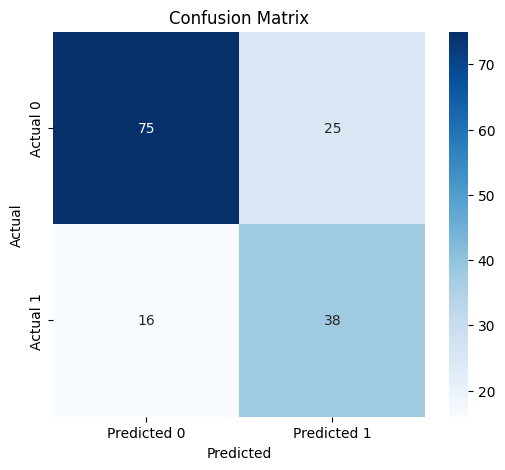

In [24]:
cm = confusion_matrix(y_test, y_pred)

print("\n--- CONFUSION MATRIX ---")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


 15. ROC CURVE

<Figure size 700x500 with 0 Axes>

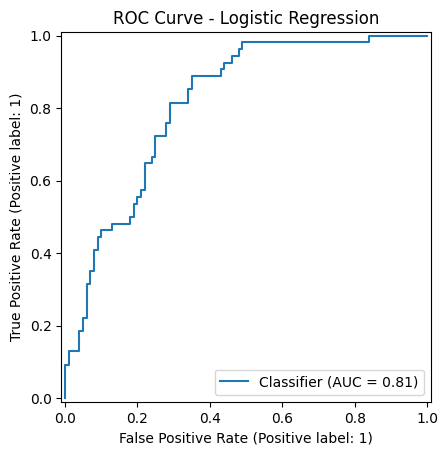

In [26]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.title("ROC Curve - Logistic Regression")
plt.show()


16. FEATURE COEFFICIENTS

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\n--- MODEL COEFFICIENTS ---")
display(coefficients)



--- MODEL COEFFICIENTS ---


,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.183483,1.183483
5,BMI,0.709592,0.709592
0,Pregnancies,0.372902,0.372902
6,DiabetesPedigreeFunction,0.287734,0.287734
7,Age,0.186434,0.186434
4,Insulin,-0.044609,0.044609
2,BloodPressure,-0.014612,0.014612
3,SkinThickness,0.013980,0.013980


17. COEFFICIENT PLOT GRAPH

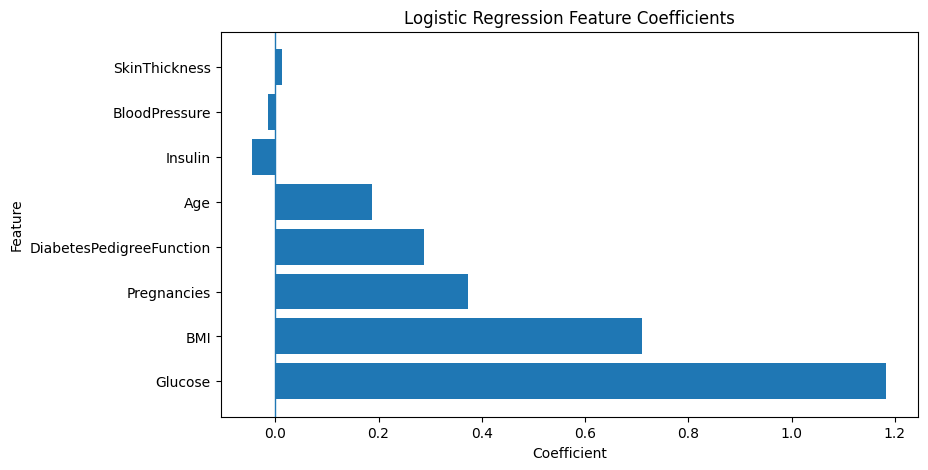

In [28]:
plt.figure(figsize=(9, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.axvline(x=0, linewidth=1)
plt.show()

18. FINAL SUMMARY

In [29]:
print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"""
Dataset              : Pima Indians Diabetes Dataset
Total samples        : {len(df)}
Total features       : {X.shape[1]}
Training samples     : {len(X_train)}
Testing samples      : {len(X_test)}

Model                : Balanced Logistic Regression
Imputation           : Median
Scaling              : StandardScaler

Accuracy             : {accuracy:.3f}
Precision            : {precision:.3f}
Recall               : {recall:.3f}
F1-score             : {f1:.3f}
ROC-AUC              : {roc_auc:.3f}

Target:
0 = No Diabetes
1 = Diabetes
""")

print("PROJECT COMPLETED SUCCESSFULLY!")


FINAL PROJECT SUMMARY

Dataset              : Pima Indians Diabetes Dataset
Total samples        : 768
Total features       : 8
Training samples     : 614
Testing samples      : 154

Model                : Balanced Logistic Regression
Imputation           : Median
Scaling              : StandardScaler

Accuracy             : 0.734
Precision            : 0.603
Recall               : 0.704
F1-score             : 0.650
ROC-AUC              : 0.813

Target:
0 = No Diabetes
1 = Diabetes

PROJECT COMPLETED SUCCESSFULLY!


## Conclusion

The Logistic Regression model was successfully trained to predict diabetes using the Pima Indians Diabetes Dataset. The model achieved an accuracy of 73.4% and a ROC-AUC score of 0.813. The recall was 70.4%, meaning the model detected approximately 70.4% of the positive cases in the test data. Glucose and BMI showed strong positive model coefficients.

This project demonstrates the use of data preprocessing, median imputation, feature scaling, Logistic Regression, and model evaluation. The model is intended for learning classification concepts and not for medical diagnosis.